K+M: [[1.46666667 0.83333333 1.03333333]
 [0.83333333 0.4        0.83333333]
 [1.03333333 0.83333333 1.46666667]]
K+M: [[1.46666667 0.83333333 0.66666667 1.03333333]
 [0.83333333 0.4        0.4        0.83333333]
 [0.66666667 0.4        0.3352381  1.        ]
 [1.03333333 0.83333333 1.         1.46666667]]
K+M: [[1.46666667 0.83333333 0.66666667 1.03333333]
 [0.83333333 0.4        0.4        0.83333333]
 [0.66666667 0.4        0.3352381  1.        ]
 [1.03333333 0.83333333 1.         1.46666667]]
K+M: [[1.46666667 0.83333333 0.66666667 0.66666667 1.03333333]
 [0.83333333 0.4        0.4        0.44190476 0.83333333]
 [0.66666667 0.4        0.3352381  0.31238095 1.        ]
 [0.66666667 0.44190476 0.31238095 0.17269841 1.33333333]
 [1.03333333 0.83333333 1.         1.33333333 1.46666667]]
K+M: [[1.46666667 0.83333333 0.66666667 0.66666667 1.03333333]
 [0.83333333 0.4        0.4        0.44190476 0.83333333]
 [0.66666667 0.4        0.3352381  0.31238095 1.        ]
 [0.66666667 0.44190476

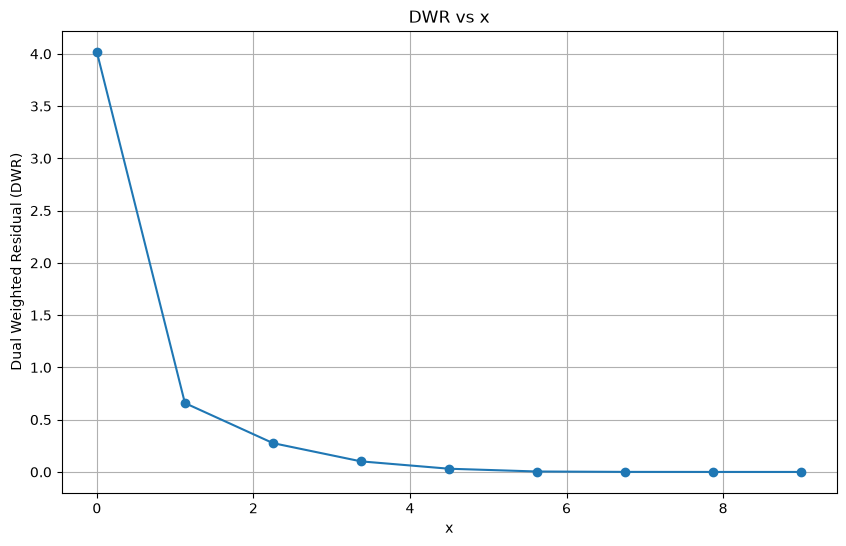

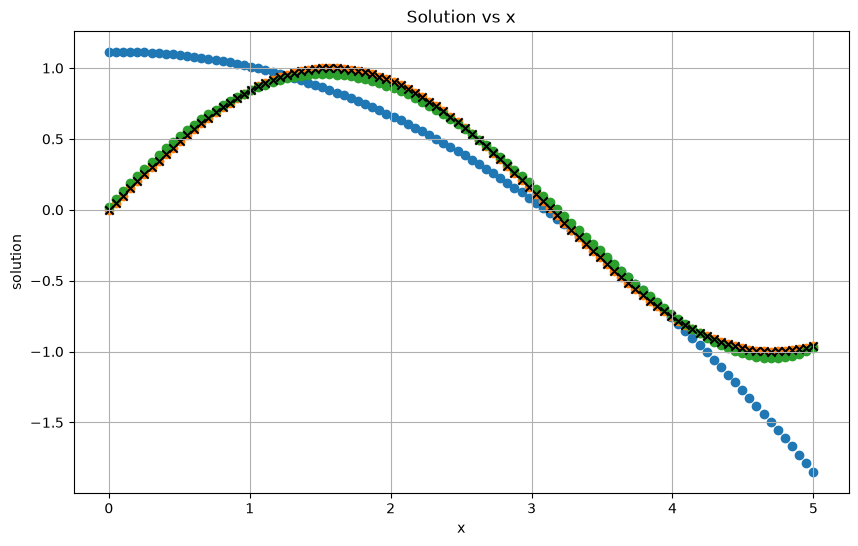

In [120]:
# Script params
# M - number of elements
# N -  number of nodes
# L length of simulation domain
# i, j - indices of gaussian integration legendre points within each cell
# n - order of hierarchical basis functions
# l - number of gauss legendre points?


import numpy as np
import scipy
import scipy.linalg
import scipy.sparse.linalg
sc = scipy
import matplotlib.pyplot as plt
 
 
def mesh(L, M, n):
    """Uniform mesh of M elements on [0, L], each carrying n+1 local DOFs
     Total global DOFs = M*n + 1."""
    nodes = np.linspace(0, L, M * n + 1)
    elements = [[e * n + i for i in range(n + 1)] for e in range(M)]
    element_p_orders = [n for i in range(M)]
    dx = L / M
    jac = [dx / 2.0 for _ in range(M)]   # dx/ds jacobian, constant for uniform mesh
    return nodes, elements, jac, element_p_orders
 
 
# def basis_eval(n, s):
#     """Hierarchical shape functions on the reference element [-1, 1]."""
#     f_base = np.zeros(n+1)
#     df_base = np.zeros(n+1)
#     for i in range(n+1):
#         if i == n+1:
#             f_base[i] = 0.5 * (1 + s)
#             df_base[i] = 0.5
#         elif i == 1:
#             f_base[i] = 0.5 * (1 - s)
#             df_base[i] = -0.5
#         else:
#             f_base[i] = 0.5 * (1 - s) * (1 + s) ** (i-1)
#             df_base[i] = 0.5 * (-(1 + s) ** (i-1) + (i-1) * (1 - s) * (1 + s) ** (i - 2))
        
#         print(f"Basis function {i}: f_base = {f_base[i]}, df_base = {df_base[i]}")
#     return f_base, df_base
 
 
def basis_eval(j, n, s):
    """Hierarchical shape functions on the reference element [-1, 1]."""

    if j == n+1:
        f_base = 0.5 * (1 + s)
        df_base = 0.5
    elif j == 1:
        f_base = 0.5 * (1 - s) * (1 + s) ** (j-1)
        df_base = -0.5
    else:
        f_base = 0.5 * (1 - s) * (1 + s) ** (j-1)
        df_base = 0.5 * (-(1 + s) ** (j-1) + (j-1) * (1 - s) * (1 + s) ** (j - 2))
        
        #print(f"Basis function {j}: f_base = {f_base}, df_base = {df_base}")
    return f_base, df_base





def K_integrals(n, i, j, alpha, beta, jacob):
    #'Integrals via gaussian quadrature for stiffness matrix'
    x, w = np.polynomial.legendre.leggauss(20)
    integral = 0.0
    for q in range(len(x)):
        #f, df = basis_eval( n, x[q])
        # mass-like term uses the jacobian, stiffness-like term divides by it
        # (physical derivative = reference derivative / jacobian)
        integral += w[q] * ( basis_eval(i, n, x[q])[1] * basis_eval(j, n, x[q])[1])
    integral = -integral*alpha/jacob
    return integral
 
 
def M_integrals(n, i, j, beta, jacob):
    #'perform integrals via gaussian quadrature for mass matrix'
    x, w = np.polynomial.legendre.leggauss(20)
    integral = 0.0
    for q in range(len(x)):
        #f, df = basis_eval(i, n, x[q])
        #print(f)
        integral += w[q] *  basis_eval(i, n, x[q])[0] * basis_eval(j, n, x[q])[0]
    integral = integral*beta*jacob
    return integral
 
 
def K_fill_local(n, alpha, beta, jacob, p_order):
    #'Fill each element stiffness matrix'
    K_loc = np.zeros((n+1, n+1))
    for i in range(1, n+2):
        for j in range(1, n+2):
            K_loc[i-1, j-1] = K_integrals(n, i, j, alpha, beta, jacob)
    return K_loc
 
 
def M_fill_local(n, beta, jacob, p_order):
    #'Filling each block for each element of M_ij'
    M_loc = np.zeros((n+1, n+1))
    for i in range(1, n+2):
        for j in range(1, n+2):
            M_loc[i-1, j-1] = M_integrals(n, i, j, beta, jacob)
    return M_loc
 
 
def K_fill_global(M, n, meshy, alpha=1, beta=1):
    #'Stiffness matrix builder '
    nodes, elements, jac, p_orders = meshy
    K_globe = np.zeros((M * n + 1, M * n + 1))
    for e in range(M):
        elem = elements[e]
        current_jacob = jac[e]
        current_p_order = p_orders[e]
        K_loc = K_fill_local(n, alpha, beta, current_jacob, current_p_order)
        for i in range(n+1):
            for j in range(n+1):
                I = elem[i]
                J = elem[j]
                K_globe[I, J] += K_loc[i, j]
    return K_globe
 
 
def M_fill_global(M, n, g, meshy, beta=1):
    #"Mass matrix builder"
    nodes, elements, jac, p_orders = meshy
    M_globe = np.zeros((M * n + 1, M * n + 1))
    for e in range(M):
        elem = elements[e]
        current_jacob = jac[e]
        current_p_order = p_orders[e]
        M_loc = M_fill_local(n, beta, current_jacob, current_p_order)
        for i in range(n+1):
            for j in range(n+1):
                I = elem[i]
                J = elem[j]
                M_globe[I, J] += M_loc[i, j]
    return M_globe
 
 
def weights_unknown(N):
    return np.zeros(N)
 
 
def G_assemble(g, M, n):
    #"excitation vector ==0 unless other g specified"
    G = np.zeros(M * n + 1)
    if g != 0:
        G[:] = g
    return G
 
 
def boundary(G, K, L, btype):
    #""'Neumann BC as specified in the problem statement. Dirichlet not yet defined, will need to do so'
    G = G.copy()
    K = K.copy()
    if btype == 'dirichlet':
        G[0] = 1
        G[-1] = -np.cos(L)
    elif btype == 'neumann':
        G[0] = 1
        G[-1] = -np.cos(L)
    return G, K
 
 
def waveguide(K, Mmat):

    # Generalized eigenproblem K x = lambda Mmat x (dense solve)
    vals, vecs = scipy.linalg.eig(K, Mmat)
    return vals, vecs
 
 
def scattering(K, G,L):
    soln = scipy.linalg.solve(K, G)
    #error = error_scatter(soln,L)
    return soln
 
 
def HW(K, G,L):
    #soln = scipy.linalg.solve(K, G)
    #error = error_scatter(soln,L)
    soln = np.linalg.inv(K).dot(G)
    
    return soln

def error_scatter(approx,L):
    exact = np.cos(np.linspace(0,L, len(approx)))
    rms_error = np.sqrt(1/L * np.sum(approx - exact)**2) / np.sqrt(1/L * np.sum(exact)**2)

    return rms_error



 
def local_errors(approx, exact, L, M,n):
    """Compute local errors for each element."""
    nodes, elements, jac, p_orders = mesh(L, M, n)
    local_errors = np.zeros(M)
    for e in range(M):
        elem = elements[e]
        approx_local = approx[elem]
        exact_local = exact[elem]
        local_errors[e] = np.sqrt(np.sum((approx_local - exact_local) ** 2))
    return local_errors


def p_refine(mesh_info, local_errors, threshold):
    sort_indices = np.argsort(local_errors,descending=True)
    sorted_errors = np.sort(local_errors,descending=True)
    top_to_refine = sort_indices[:len(sorted_errors)//3]
    refine = local_errors[top_to_refine]
    new_mesh_info = mesh_info
    mesh_elem = mesh_info[1]
    for i in range(len(refine)):
        if refine[i] > threshold:
            new_mesh_info[3][mesh_elem.index(top_to_refine[i])] += 1  
        else:
            break
    return new_mesh_info


def dual_weight_residual_global(solution, higher_order_soln):
    '''Computing DWR for the whole domain, using the solution and enriched solution to error estimate.
    In this case the operator L is self adjoint, so dual is same as primal, but the excitation is 
    then the divergence of the primal solution, giving the "charge" density to the primals E field.'''

    
    soln = solution
    enriched_soln = higher_order_soln
    interpolated_soln = np.interp(np.linspace(0, 1, len(enriched_soln)), np.linspace(0, 1, len(soln)), soln)
    error_estimate = np.gradient(enriched_soln) - np.gradient(interpolated_soln)
    inner_product = np.dot(enriched_soln, interpolated_soln)
    DWR = np.abs(inner_product) * error_estimate
    #print("DWR:", DWR)

    return DWR



def basis_scale_plotting(solution_in, L,M,n):
    '''From Cam Key code (adapted) scales the soltiuon to the physical output!'''
    s = np.linspace(-1,1,100)
    plot_samps = np.zeros(M*100)
    #nodes, elements, jac, p_orders = mesh(L, M, n)
    s_len = len(s)
    for e in range(M):
        
        for j_local in range(1,n+2):
            
            #coeff = solution_in[e*s_len + ]
            #basis_idx = j_local + 1  # basis_eval expects 1..n+1
            for k in range(s_len):
                plot_samps[e * s_len + k] += solution_in[e * n + j_local - 1] * basis_eval(j_local, n, s[k])[0]
    return plot_samps




'''
 
def main(type, L, M, n, g=0):
    mesher = mesh(L, M, n)
    #rint("Mesher:", mesher)
    K = K_fill_global(M, n, mesher)
    print("K:", K)
    
    #print(K)
    Mmat = M_fill_global(M, n, g, mesher)
    print("Mmat:", Mmat)
    #print(Mmat)
    G = G_assemble(g, M, n)
    G, K = boundary(G, K, L, 'neumann')
    print("G:", G)
    weights = weights_unknown(M * n + 1)
 
    if type == 'waveguide':
        soln = waveguide(K, Mmat)
    elif type == 'scattering':
        K = K+Mmat
        
        soln = scattering(K, G, L)
        

            
    else:
        K = K+Mmat
        
        soln = HW(K, G, L)

    return soln

'''

def p_refine_DWR_global(threshold,type, L, M, n, g=0):
    #Use the DWR to refine the mesh with p refinement only globally
    low_order,low_order_plotting = main(type, L, M, n, g)
    high_order, high_order_plotting = main(type, L, M, n+1, g)
    DWR = dual_weight_residual_global( low_order_plotting, high_order_plotting)
    DWR = DWR.max()
    #print(DWR)
    return DWR, low_order_plotting


def main(type, L, M, n, g=0):
    
    mesher = mesh(L, M, n)
    #rint("Mesher:", mesher)
    K = K_fill_global(M, n, mesher)
    #print("K:", K)
    #print("Shape of K:", np.shape(K))
    #print("K:", K)
    
    #print(K)
    Mmat = M_fill_global(M, n, g, mesher)
    #print("Mmat:", Mmat)
    #print(Mmat)
    G = G_assemble(g, M, n)
    G, K = boundary(G, K, L, 'neumann')
    #print("K:", G)
    weights = weights_unknown(M * n + 1)
 
    if type == 'waveguide':
        soln = waveguide(K, Mmat)
    elif type == 'scattering':
        K = K+Mmat
        
        soln = scattering(K, G, L)
        

            
    else:
        K = K+Mmat
        print("K+M:", K)
        #print("Shape of K+M:", np.shape(K))
        soln = HW(K, G, L)
        plotting_soln = basis_scale_plotting(soln, L, M, n)
        #print("Plotting solution shape:", solution)

    return soln, plotting_soln

solutions = []
dwr_max = []
for i in range(9):
    dwr, solution = p_refine_DWR_global(threshold=0.01, type='HW', L=5, M=1, n=2+i)
    dwr_max.append(dwr)
    solutions.append(solution)

#dwr, solution = p_refine_DWR_global(threshold=0.01, type='HW', L=5, M=1, n=9)

#solution, plotting_solution = main('HW', L=5, M=1, n=9)

#refined_soln, DWR = main('HW', L=5, M=10, n=2)
'''
if __name__ == "__main__":
    iter = [3, 5, 10, 20, 50, 100]
    errors = []
    for i in iter:
        result = main('HW', L=5, M=i, n=2)
        errors.append(result[1])
        
        print(f"Result for M={i}:")
        #print(result[0])
    #esult = main('HW', L=5, M=100, n=1)


    iter2= [3, 4,5,6,7,8,9]
    errors2= []
    for j in iter2:
        result2= main('HW', L=5, M=1,n=j)
        errors2.append(result2[1])
        
        print(f"Result for n={j}:")
        #print(result[0])
    #esult = main('HW', L=5, M=100, n=1)

    
    #rint("Result:")
    #rint(result)



'''
print(solution)
# robust plotting of the numerical result
plt.figure(figsize=(10, 6))
x = np.linspace(0, len(dwr_max), len(dwr_max))
plt.plot(x, dwr_max,marker='o')
plt.xlabel('x')
plt.ylabel('Dual Weighted Residual (DWR)')
plt.title('DWR vs x')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
x = np.linspace(0, 5, len(solutions[0]))
x2 = np.linspace(0, 5, len(solutions[8]))
x3 = np.linspace(0, 5, len(solutions[1]))

plt.scatter(x, solutions[0])
plt.scatter(x2, solutions[8])
plt.scatter(x3, solutions[2])
plt.scatter(x, np.sin(x), label='Exact Solution', color='black', marker='x')
plt.xlabel('x')
plt.ylabel('solution')
plt.title('Solution vs x')
plt.grid(True)
plt.show()


#plt.figure(figsize=(10, 6))


#errors = [result[1,i] for i in range(len(result))]
#plt.plot(iter, errors,marker='o')
#plt.xlabel('x')
#plt.ylabel('solution')
#plt.title('Solution vs x')
#plt.grid(True)
#plt.show()

